Reference: 
https://www.kaggle.com/ryanholbrook/principal-component-analysis#kln-21

https://www.geeksforgeeks.org/implementing-pca-in-python-with-scikit-learn/#:~:text=%20Python%20Implementation%3A%20%201%20To%20implement%20PCA,the%20variance%20explained%20by%20each%20principal...%20More%20

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_selection import mutual_info_regression

from xgboost.sklearn import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import recall_score, f1_score, precision_score, precision_recall_fscore_support
from sklearn.metrics import accuracy_score

import seaborn as sns

In [5]:
# 110 cols of 267 cols
x_cols = [ 'bid',  'bid_size', 'ask',  'ask_size', 'last', 'last_size', 'hist_volatility',  'implied_volatility', 
'n5s',  'n15s', 'n30s', 'n60s', 'n300s',    'n600s', 
'n5s_delta',    'n15s_delta',   'n30s_delta',   'n60s_delta',   'n300s_delta',  'n600s_delta',
'c_w1_n3_ask',  'c_w1_n3_bid',  'c_w1_n3_last', 'c_w1_n3_time_value',   'c_w1_n3_theta',    'c_w1_n3_implied_volatility',               
'c_w1_n2_ask',  'c_w1_n2_bid',  'c_w1_n2_last', 'c_w1_n2_time_value',   'c_w1_n2_theta',    'c_w1_n2_implied_volatility',               
'c_w1_n1_ask',  'c_w1_n1_bid',  'c_w1_n1_last', 'c_w1_n1_time_value',   'c_w1_n1_theta',    'c_w1_n1_implied_volatility',               
'c_w1_p1_ask',  'c_w1_p1_bid',  'c_w1_p1_last', 'c_w1_p1_time_value',   'c_w1_p1_theta',    'c_w1_p1_implied_volatility',               
'c_w1_p2_ask',  'c_w1_p2_bid',  'c_w1_p2_last', 'c_w1_p2_time_value',   'c_w1_p2_theta',    'c_w1_p2_implied_volatility',               
'c_w1_p3_ask',  'c_w1_p3_bid',  'c_w1_p3_last', 'c_w1_p3_time_value',   'c_w1_p3_theta',    'c_w1_p3_implied_volatility',               
'c_w2_n3_ask',  'c_w2_n3_bid',  'c_w2_n3_last', 'c_w2_n3_time_value',   'c_w2_n3_theta',    'c_w2_n3_implied_volatility',               
'c_w2_n2_ask',  'c_w2_n2_bid',  'c_w2_n2_last', 'c_w2_n2_time_value',   'c_w2_n2_theta',    'c_w2_n2_implied_volatility',               
'c_w2_n1_ask',  'c_w2_n1_bid',  'c_w2_n1_last', 'c_w2_n1_time_value',   'c_w2_n1_theta',    'c_w2_n1_implied_volatility',               
'c_w2_p1_ask',  'c_w2_p1_bid',  'c_w2_p1_last', 'c_w2_p1_time_value',   'c_w2_p1_theta',    'c_w2_p1_implied_volatility',               
'c_w2_p2_ask',  'c_w2_p2_bid',  'c_w2_p2_last', 'c_w2_p2_time_value',   'c_w2_p2_theta',    'c_w2_p2_implied_volatility',               
'c_w2_p3_ask',  'c_w2_p3_bid',  'c_w2_p3_last', 'c_w2_p3_time_value',   'c_w2_p3_theta',    'c_w2_p3_implied_volatility',               
'c_w3_n3_ask',  'c_w3_n3_bid',  'c_w3_n3_last', 'c_w3_n3_time_value',   'c_w3_n3_theta',    'c_w3_n3_implied_volatility',               
'c_w3_n2_ask',  'c_w3_n2_bid',  'c_w3_n2_last', 'c_w3_n2_time_value',   'c_w3_n2_theta',    'c_w3_n2_implied_volatility',               
'c_w3_n1_ask',  'c_w3_n1_bid',  'c_w3_n1_last', 'c_w3_n1_time_value',   'c_w3_n1_theta',    'c_w3_n1_implied_volatility',               
'c_w3_p1_ask',  'c_w3_p1_bid',  'c_w3_p1_last', 'c_w3_p1_time_value',   'c_w3_p1_theta',    'c_w3_p1_implied_volatility',               
'c_w3_p2_ask',  'c_w3_p2_bid',  'c_w3_p2_last', 'c_w3_p2_time_value',   'c_w3_p2_theta',    'c_w3_p2_implied_volatility',               
'c_w3_p3_ask',  'c_w3_p3_bid',  'c_w3_p3_last', 'c_w3_p3_time_value',   'c_w3_p3_theta',    'c_w3_p3_implied_volatility'
]

# x_cols = ['volume', 'c_w1_p3_theta','c_w1_p2_theta','c_w3_n2_theta','c_w2_p3_theta','c_w3_p1_theta','c_w2_n1_theta','c_w3_n1_theta','c_w3_n3_theta','c_w2_n2_theta','c_w2_p1_theta','c_w2_p2_theta','c_w1_n1_theta','c_w1_p1_theta','c_w3_p3_theta','c_w2_n3_theta','c_w3_p2_theta', 'c_w1_n2_theta','c_w1_n3_theta','implied_volatility','hist_volatility']
y_cols = ['p30s_bucket']  # ,  'p5s_bucket', 'p30s_bucket', 'p60s_bucket']
bin_counts = 5

file_list = ['ml_cp18/ml_cp18_AAPL20220103.csv','ml_cp18/ml_cp18_AAPL20220104.csv', 'ml_cp18/ml_cp18_AAPL20220105.csv', 'ml_cp18/ml_cp18_AAPL20220106.csv', 'ml_cp18/ml_cp18_AAPL20220107.csv',]
file_list_train = file_list[:-1]
file_list_test = file_list[-1:]


# PCA Analysis of all columns and all files

## Load All Data

In [6]:
import os
data = None
for file in file_list:
    file = "../" + file
    assert os.path.exists(file), "Data file does not exist!"
    data_tmp = pd.read_csv(file, low_memory=False)
    if data is None:
        data = data_tmp
    else:
        data = data.append(data_tmp, ignore_index=True)
print ('loaded data', data.shape)
data = data.dropna()
print ('after dropna', data.shape)

loaded data (69316, 267)
after dropna (46789, 267)


## Scale Data

In [101]:
# Get the numeric cols to scale
numeric_cols = [] 
for i, v in data.dtypes.items():
    # print(f'index: {i} and value: {v}')
    if v != 'object': numeric_cols.append(i)
#print(numeric_cols)
data_numbers = data [ numeric_cols ]
data_target = data [ y_cols ]
print(data_numbers.shape)
x_cols_numeric = data_numbers.columns
print (x_cols_numeric)

(46789, 248)
Index(['con_id', 'time', 'bid', 'bid_size', 'ask', 'ask_size', 'last',
       'last_size', 'volume', 'hist_volatility',
       ...
       'p30s_bucket', 'p60s_bucket', 'p300s_bucket', 'p600s_bucket',
       'n5s_bucket', 'n15s_bucket', 'n30s_bucket', 'n60s_bucket',
       'n300s_bucket', 'n600s_bucket'],
      dtype='object', length=248)


In [8]:
scalar = StandardScaler()
scalar.fit(data_numbers)
data_scaled = scalar.transform(data_numbers)

## Perform PCA Analysis

Text(0, 0.5, 'Cumulative explained variance')

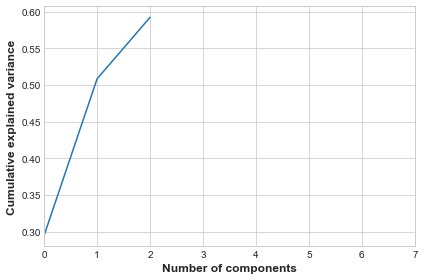

In [95]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3).fit(data_scaled)
pca_transformed = pca.transform(data_scaled)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlim(0,7,1)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')

In [97]:
pca.components_


array([[-0.0859, -0.0044, -0.0859, -0.0037, -0.0859,  0.0009, -0.0153,
        -0.0721,  0.0483, -0.0053, -0.0859, -0.0859,  0.0003, -0.0859,
         0.0005, -0.0858,  0.0004, -0.0858,  0.0007, -0.0858,  0.001 ,
        -0.0857, -0.0036, -0.0859, -0.0859, -0.086 , -0.086 , -0.086 ,
        -0.0864,  0.0136, -0.0867, -0.003 , -0.0858,  0.0146, -0.0826,
        -0.0169, -0.0663, -0.0727, -0.0532,  0.0018,  0.0693, -0.0026,
        -0.0989, -0.0338, -0.0997, -0.0092, -0.0976,  0.0025, -0.0663,
        -0.0484,  0.0061,  0.067 ,  0.063 , -0.1125, -0.0588, -0.1126,
        -0.0574, -0.1123,  0.0086, -0.0663, -0.0378,  0.0698,  0.0758,
        -0.0163, -0.1047,  0.0486, -0.1046,  0.0442, -0.1046,  0.0052,
        -0.0663, -0.0002,  0.0611,  0.0861, -0.0568, -0.0992,  0.035 ,
        -0.0977,  0.0063, -0.0989,  0.0032, -0.0663,  0.0295,  0.0605,
         0.0893, -0.0589, -0.1   ,  0.0638, -0.0813,  0.0009, -0.0995,
         0.0006, -0.0663,  0.0483,  0.0601,  0.0769,  0.0195, -0.0829,
      

In [98]:
np.set_printoptions(suppress=True, precision=4)
print(pca.explained_variance_ratio_)
np.set_printoptions()  # reset print options

[0.2952 0.2133 0.0839]


Text(0, 0.5, 'pc2')

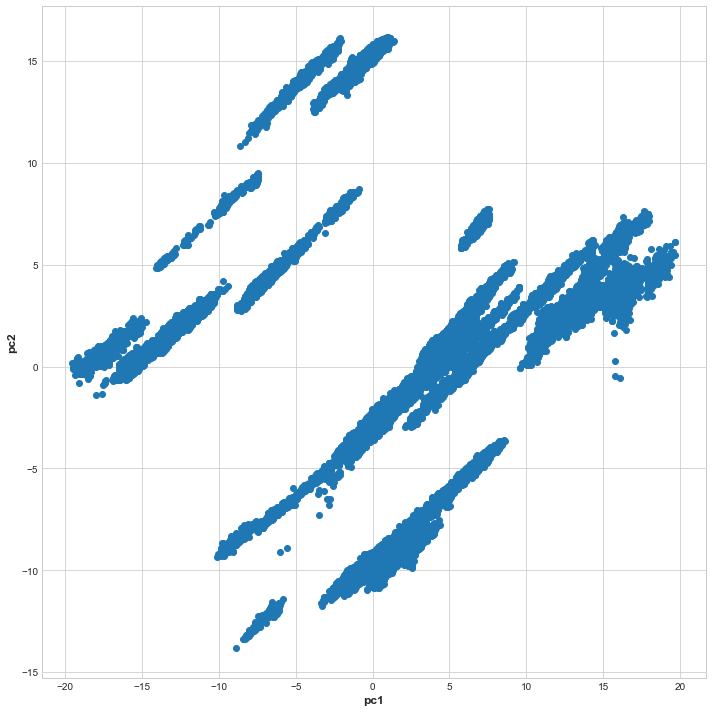

In [108]:
plt.figure(figsize=(10,10))
plt.scatter(pca_transformed[:,0],pca_transformed[:,1],c=data_target.astype('int'),cmap='plasma')
plt.xlabel('pc1')
plt.ylabel('pc2')

array([<AxesSubplot:title={'center':'% Explained Variance'}, xlabel='Component'>,
       <AxesSubplot:title={'center':'% Cumulative Variance'}, xlabel='Component'>],
      dtype=object)

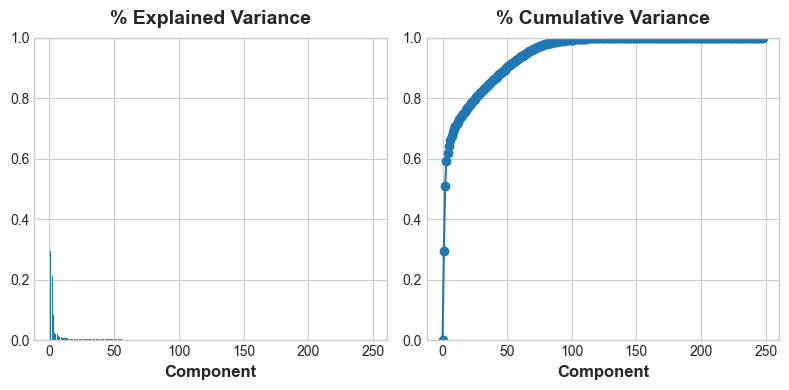

In [20]:
plot_variance(pca)

In [47]:
pca_transformed

array([[  4.208 ,  14.7265,   0.0602, ...,   0.    ,  -0.    ,  -0.    ],
       [  4.3923,  14.7404,   0.3215, ...,  -0.    ,   0.    ,  -0.    ],
       [  5.1179,  13.9818,  -0.0002, ...,   0.    ,   0.    ,  -0.    ],
       ...,
       [-16.0512,   3.1499,  -9.2616, ...,  -0.    ,  -0.    ,  -0.    ],
       [-15.7954,   0.633 , -10.8086, ...,  -0.    ,  -0.    ,  -0.    ],
       [-15.8303,  -0.0985, -11.7717, ...,  -0.    ,  -0.    ,  -0.    ]])

In [150]:
pca.explained_variance_ratio_

array([0.2952, 0.2133, 0.0839])

### Graphing all target columns (p0 - p4)

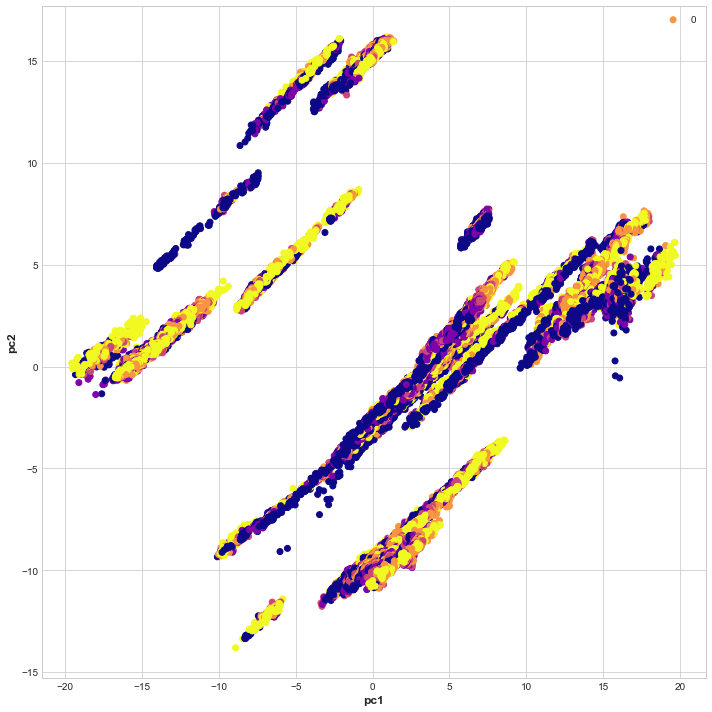

In [147]:
plt.figure(figsize=(10,10))
plt.scatter(pca_transformed[:,0],pca_transformed[:,1],c=(data_target.astype('int')).iloc[:, 0],cmap='plasma')
plt.xlabel('pc1')
plt.ylabel('pc2')

plt.legend(['0', '1', '2', '3', '4', '5'])
plt.grid(True)
plt.show()

Text(0.5, 0, 'PC3')

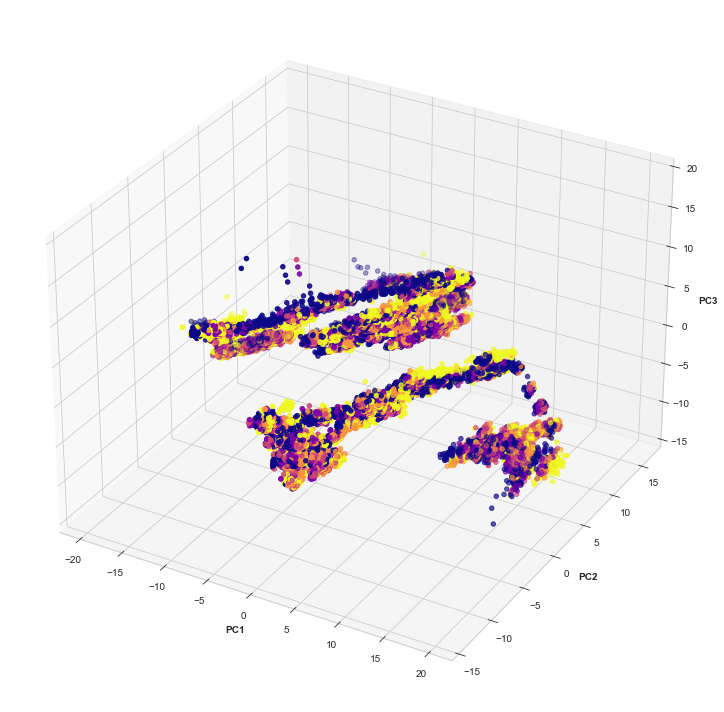

In [149]:
# import relevant libraries for 3d graph
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,10))

# choose projection 3d for creating a 3d graph
axis = fig.add_subplot(111, projection='3d')
# x[:,0]is pc1,x[:,1] is pc2 while x[:,2] is pc3
axis.scatter(pca_transformed[:,0],pca_transformed[:,1],pca_transformed[:,2],c=(data_target.astype('int')).iloc[:, 0],cmap='plasma')
#axis.scatter(x[:,0],x[:,1],x[:,2], c=data['target'],cmap='plasma')
axis.set_xlabel("PC1", fontsize=10)
axis.set_ylabel("PC2", fontsize=10)
axis.set_zlabel("PC3", fontsize=10)


### Graphing each target class

Text(0.5, 0, 'PC3')

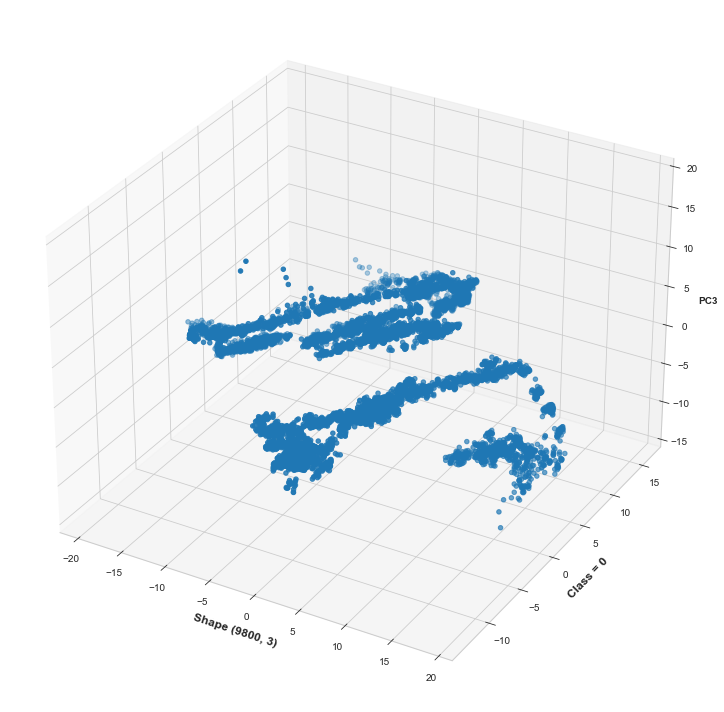

In [175]:
target_class = 0
fig = plt.figure(figsize=(10,10))
# choose projection 3d for creating a 3d graph
axis = fig.add_subplot(111, projection='3d')
# x[:,0]is pc1,x[:,1] is pc2 while x[:,2] is pc3
one_class = pca_transformed[ data [ 'p30s_bucket' ] == target_class ] 
axis.scatter(one_class[:,0],one_class[:,1],one_class[:,2],cmap='plasma')
#axis.scatter(x[:,0],x[:,1],x[:,2], c=data['target'],cmap='plasma')
axis.set_xlabel("Shape " + str(one_class.shape), fontsize=12)
axis.set_ylabel("Class = " + str(target_class) , fontsize=12)
axis.set_zlabel("PC3", fontsize=10)


Text(0.5, 0, 'PC3')

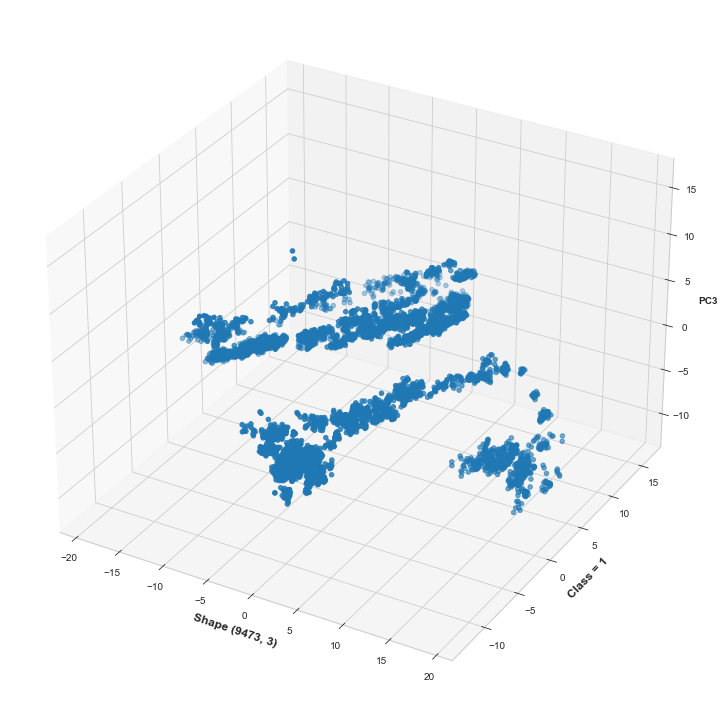

In [174]:
target_class = 1
fig = plt.figure(figsize=(10,10))
# choose projection 3d for creating a 3d graph
axis = fig.add_subplot(111, projection='3d')
# x[:,0]is pc1,x[:,1] is pc2 while x[:,2] is pc3
one_class = pca_transformed[ data [ 'p30s_bucket' ] == target_class ] 
axis.scatter(one_class[:,0],one_class[:,1],one_class[:,2],cmap='plasma')
#axis.scatter(x[:,0],x[:,1],x[:,2], c=data['target'],cmap='plasma')
axis.set_xlabel("Shape " + str(one_class.shape), fontsize=12)
axis.set_ylabel("Class = " + str(target_class) , fontsize=12)
axis.set_zlabel("PC3", fontsize=10)



Text(0.5, 0, 'PC3')

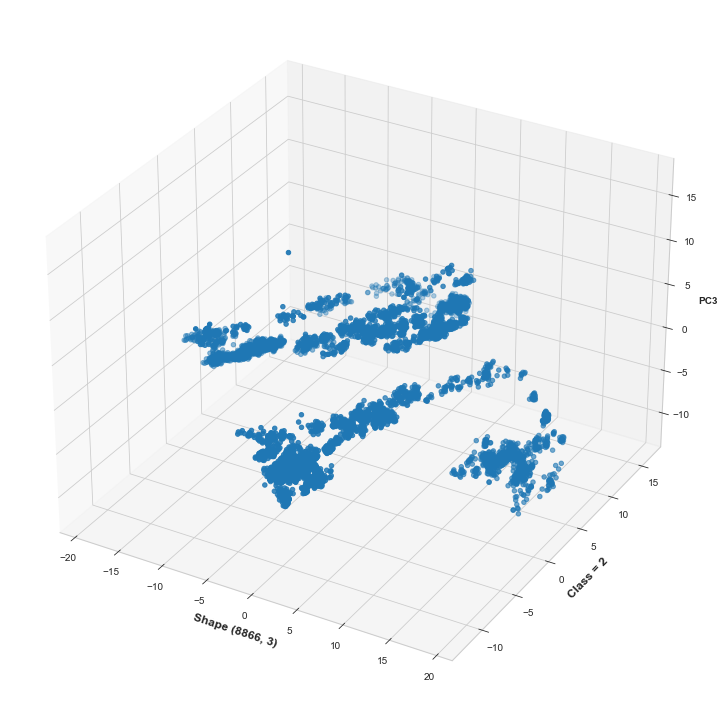

In [173]:
target_class = 2
fig = plt.figure(figsize=(10,10))
# choose projection 3d for creating a 3d graph
axis = fig.add_subplot(111, projection='3d')
# x[:,0]is pc1,x[:,1] is pc2 while x[:,2] is pc3
one_class = pca_transformed[ data [ 'p30s_bucket' ] == target_class ] 
axis.scatter(one_class[:,0],one_class[:,1],one_class[:,2],cmap='plasma')
#axis.scatter(x[:,0],x[:,1],x[:,2], c=data['target'],cmap='plasma')
axis.set_xlabel("Shape " + str(one_class.shape), fontsize=12)
axis.set_ylabel("Class = " + str(target_class) , fontsize=12)
axis.set_zlabel("PC3", fontsize=10)



Text(0.5, 0, 'PC3')

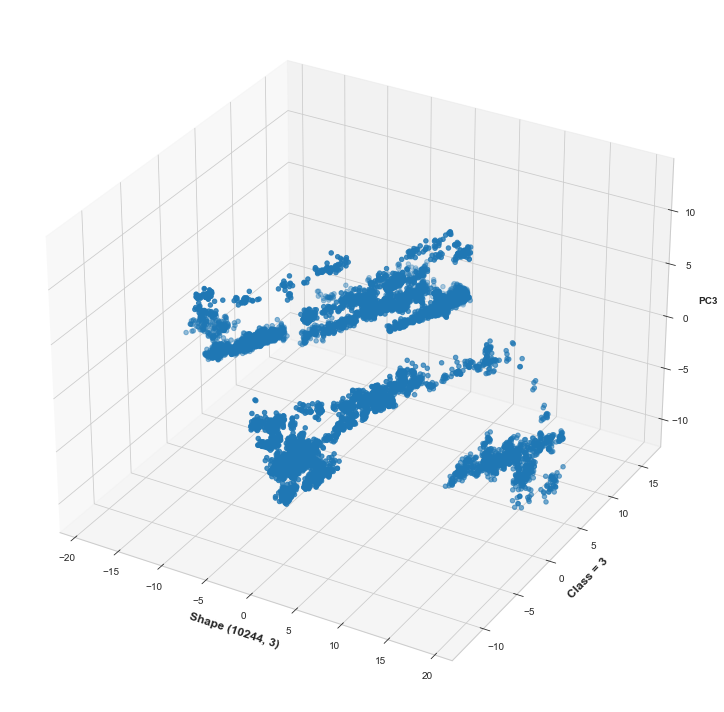

In [171]:
target_class = 3
fig = plt.figure(figsize=(10,10))
# choose projection 3d for creating a 3d graph
axis = fig.add_subplot(111, projection='3d')
# x[:,0]is pc1,x[:,1] is pc2 while x[:,2] is pc3
one_class = pca_transformed[ data [ 'p30s_bucket' ] == target_class ] 
axis.scatter(one_class[:,0],one_class[:,1],one_class[:,2],cmap='plasma')
#axis.scatter(x[:,0],x[:,1],x[:,2], c=data['target'],cmap='plasma')
axis.set_xlabel("Shape " + str(one_class.shape), fontsize=12)
axis.set_ylabel("Class = " + str(target_class) , fontsize=12)
axis.set_zlabel("PC3", fontsize=10)



Text(0.5, 0, 'PC3')

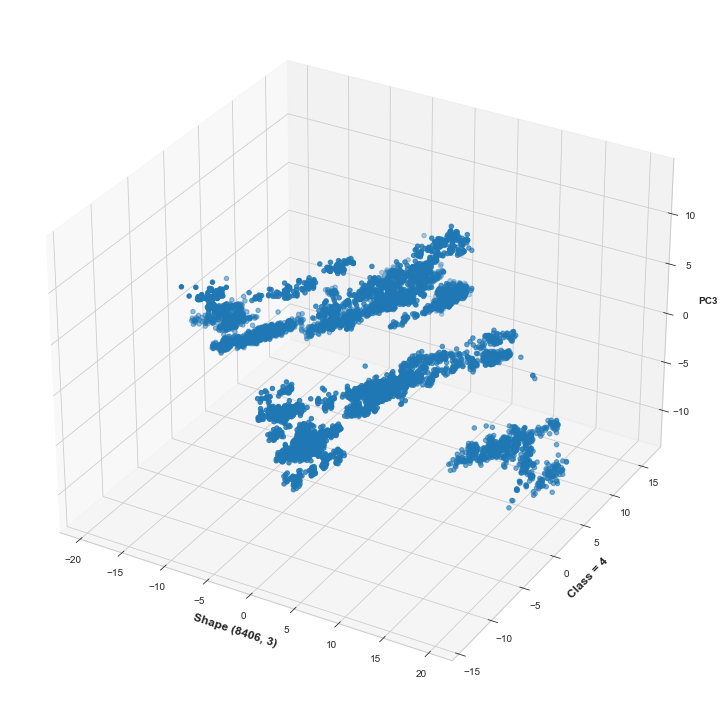

In [172]:
target_class = 4
fig = plt.figure(figsize=(10,10))
# choose projection 3d for creating a 3d graph
axis = fig.add_subplot(111, projection='3d')
# x[:,0]is pc1,x[:,1] is pc2 while x[:,2] is pc3
one_class = pca_transformed[ data [ 'p30s_bucket' ] == target_class ] 
axis.scatter(one_class[:,0],one_class[:,1],one_class[:,2],cmap='plasma')
#axis.scatter(x[:,0],x[:,1],x[:,2], c=data['target'],cmap='plasma')
axis.set_xlabel("Shape " + str(one_class.shape), fontsize=12)
axis.set_ylabel("Class = " + str(target_class) , fontsize=12)
axis.set_zlabel("PC3", fontsize=10)

